In [1]:
import sys
sys.path.append('/Users/rifatordulu/Developer/lstm-stock-price-prediction')
# sys.path.append('/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers')

%run "../helpers/data_manipulator.py"
%run "../helpers/yfinance_data_fetcher.py"

from custom_objects import register_custom_objects
# Register globally
register_custom_objects()

In [2]:
from keras.models import load_model

# Prepare model location and name
model_location = "../models/"
model_name = "model_special_5y-sequence-limited-stocks-dropout-0.2-800-400-400-100-lstm-and-more-data-ticker-embedding_epoch_200_lr1e-05_batch64_seqsize64_lossbinary_crossentropy.keras"

# Load the best performing model
best_model = load_model(model_location + model_name)

2025-01-05 21:21:01.685711: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-01-05 21:21:01.685734: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-01-05 21:21:01.685738: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-01-05 21:21:01.685755: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-05 21:21:01.685769: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### LOAD VECTORS FOR TODAY

In [3]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler

stocks = [
    "MSFT", "NVDA", "AMZN",
     "GOOGL"
    , "META",
    "TSLA"
    , "AMD"
    , "SPOT", "DASH"
    , "QCOM", "JPM", "GS", "KO", "PEP"
]

# stocks = [
#      "AAPL", "MSFT",
#     # "NVDA",
#     "AMZN", "GOOGL", "META"#, "TSLA"
#           # , "BRK-B", "LLY", "V", "XOM", "UNH", "MA", "AVGO"
#     , "JNJ", "WMT", "PG", "JPM", "HD", "MRK", "PEP", "KO"
# # , "PFE", "ABBV", "COST", "TMO", "DIS", "CSCO", "MCD", "DHR"
# # , "NKE", "LIN", "ACN", "ABT", "CVX", "NEE", "TXN", "MDT", "CRM"
# # , "ORCL", "UPS", "PM", "AMD", "HON", "MS", "UNP", "IBM", "INTC"
# # , "AMGN", "QCOM", "SPGI", "RTX", "LOW", "GS", "CAT", "NOW", "BLK"
# # , "GE", "LMT", "SCHW", "ADBE", "ELV", "PLD", "BKNG", "T", "DE"
# # , "SBUX", "ISRG", "MDLZ", "MO", "ADP", "SYK", "ZTS", "CB", "CI"
# # , "SO", "MMC", "GILD", "USB", "PGR", "FIS", "ADI"
#           #, "FISV"
#           # , "HCA", "ITW", "EQIX", "APD", "BMY", "TJX", "CL"
# # , "D", "EMR", "GM", "HES", "ICE", "KMB", "LHX", "MAR", "TMUS", "VZ", "WBA"
#          ]

data_frame = construct_values_for_model(ticker_symbols=stocks, use_for_last_day_prediction=False, verbose=False, refresh=False, data_interval="6mo")

fetch_finance_data_for_tickers: just returning file name: MSFT for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: NVDA for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: AMZN for interval: 6mo


/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:165: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, data], ignore_index=True)
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior 

fetch_finance_data_for_tickers: just returning file name: GOOGL for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: META for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: TSLA for interval: 6mo


/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame c

fetch_finance_data_for_tickers: just returning file name: AMD for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: SPOT for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: DASH for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: QCOM for interval: 6mo


/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame c

fetch_finance_data_for_tickers: just returning file name: JPM for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: GS for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: KO for interval: 6mo
fetch_finance_data_for_tickers: just returning file name: PEP for interval: 6mo


/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])
/Users/rifatordulu/Developer/lstm-stock-price-prediction/helpers/data_manipulator.py:111: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_frame = pd.concat([data_frame, to_concat])


In [4]:
from sklearn.preprocessing import LabelEncoder
import pickle

### ASSIGN INT VALUES INSTEAD OF Ticker and Sector names

stock_names = np.unique(data_frame["Ticker"])
sector_names = np.unique(data_frame["Sector"])

# Check if label_encoder.pkl exists
label_encoder_path = 'label_encoder.pkl'
label_encoder = LabelEncoder()

stock_ids = label_encoder.fit_transform(stock_names)

# Save the LabelEncoder to a file
with open(label_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print("Initialized and saved new LabelEncoder.")

# Mapping example: {'AMZN': 0, 'AAPL': 1, ...}
stock_dict = dict(zip(stock_names, stock_ids))
print(stock_dict)

data_frame["Orig_Ticker"] = data_frame["Ticker"]
data_frame["Ticker"] = data_frame["Ticker"].replace(stock_dict)


# Check if label_encoder.pkl exists
sector_encoder_path = 'sector_encoder.pkl'
sector_encoder = LabelEncoder()

sector_ids = sector_encoder.fit_transform(sector_names)

# Save the LabelEncoder to a file
with open(sector_encoder_path, 'wb') as f:
    pickle.dump(sector_encoder, f)
print("Initialized and saved new LabelEncoder.")

# Mapping example: {'AMZN': 0, 'AAPL': 1, ...}
sector_dict = dict(zip(sector_names, sector_ids))
print(dict(zip(sector_names, sector_ids)))

data_frame["Orig_Sector"] = data_frame["Sector"]
data_frame["Sector"] = data_frame["Sector"].replace(sector_dict)

Initialized and saved new LabelEncoder.
{'AMD': 0, 'AMZN': 1, 'DASH': 2, 'GOOGL': 3, 'GS': 4, 'JPM': 5, 'KO': 6, 'META': 7, 'MSFT': 8, 'NVDA': 9, 'PEP': 10, 'QCOM': 11, 'SPOT': 12, 'TSLA': 13}
Initialized and saved new LabelEncoder.
{'Auto Tech': 0, 'Consumer Retail': 1, 'Consumer Tech': 2, 'Entertainment': 3, 'Financials': 4, 'Tech': 5}


/var/folders/1n/8vt634f15059yz_p3_whxnk80000gn/T/ipykernel_4837/265563947.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame["Ticker"] = data_frame["Ticker"].replace(stock_dict)
/var/folders/1n/8vt634f15059yz_p3_whxnk80000gn/T/ipykernel_4837/265563947.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame["Sector"] = data_frame["Sector"].replace(sector_dict)


In [5]:
# BElow verifying the arr conversions work properly. check the values...
print(data_frame.iloc[0]["LstmData"].iloc[0])
print(np.array(data_frame["LstmData"].to_list())[0][0])


print(f"test_data data shape:{data_frame.shape} and test_data data columns: {data_frame.columns}")

Open                0.981135
High                0.984349
Low                 0.985833
Close               0.985478
Volume              0.180049
High-Low-Ratio      0.000000
High-Open-Ratio     0.200666
Close-Open-Ratio    0.686188
Next-Day-Open       0.984176
Name: 0, dtype: float64
[0.98113488 0.98434926 0.98583301 0.98547776 0.18004934 0.
 0.20066626 0.68618802 0.98417555]
test_data data shape:(868, 7) and test_data data columns: Index(['LstmData', 'Date', 'Ticker', 'Sector', 'y-value', 'Orig_Ticker',
       'Orig_Sector'],
      dtype='object')


In [6]:
X_test = np.array(data_frame["LstmData"].to_list())
X_test_ticker = np.array(data_frame["Ticker"].to_list())
X_test_sector = np.array(data_frame["Sector"].to_list())
y_test = np.array(data_frame["y-value"].to_list())


print(X_test.shape)
print(y_test.shape)
print(f"total number of positives in test data: {np.sum(y_test)}")

(868, 64, 9)
(868,)
total number of positives in test data: 73.0


In [7]:
# Predict stock price for all data splits
y_predict = best_model.predict([X_test,X_test_ticker,X_test_sector])
data_frame['y-predict'] = y_predict

2025-01-05 21:21:03.028061: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 


In [8]:
def make_predictions(threshold = 0.5):
    
    tp_column = f"TP-{threshold}"
    fp_column = f"FP-{threshold}"
    fn_column = f"FN-{threshold}"

    real_y_values = data_frame[data_frame["y-value"] == 1.0]
    
    data_frame[tp_column] = (data_frame["y-predict"] > threshold) & (data_frame["y-value"] == 1.0)
    data_frame[fp_column] = (data_frame["y-predict"] > threshold) & (data_frame["y-value"] == 0.0)
    data_frame[fn_column] = (data_frame["y-predict"] <= threshold) & (data_frame["y-value"] == 1.0)
    
    
    tps = data_frame.loc[data_frame[tp_column] == True]
    fps = data_frame.loc[data_frame[fp_column] == True]
    fns = data_frame.loc[data_frame[fn_column] == True]

    print(f"tps:{len(tps)} fps:{len(fps)} fns:{len(fns)}")

    if len(tps) + len(fps) == 0 :
        print(f"No prediction at this threshold")
    else:
        print(f"EVAL RESULTS: \n Precision: {len(tps) / (len(tps) + len(fps))} \n Recall: {len(tps) / (len(tps) + len(fns))}")
        print(f"RANDOM GUESS at 1.0 recall: \n Precision: {len(real_y_values) / len(data_frame)}")
    
    # Group by 'Category' and count the total occurrences
    tps_grouped = tps.groupby('Date').size().reset_index(name='Total Count')
    fps_grouped = fps.groupby('Date').size().reset_index(name='Total Count')
    print(f"PRINTING TRUE POSITIVE METRICS: \n {tps_grouped}")
    print(f"PRINTING FALSE POSITIVE METRICS: \n {fps_grouped}")
    
    data_frame.sort_values(by='Date', ascending=True, inplace=True)

    
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        print(f"True Positives: \n {data_frame[data_frame[tp_column] == 1]}")
        print(f"False Positives: \n {data_frame[data_frame[fp_column] == 1]}")

    return data_frame

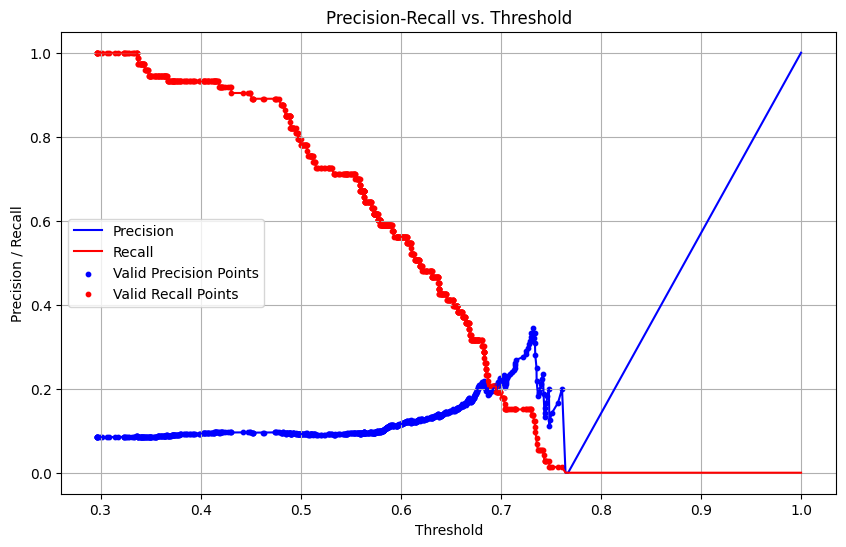

In [9]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

precision, recall, thresholds = precision_recall_curve(data_frame["y-value"].to_list(), data_frame["y-predict"].to_list())

# Extend thresholds to include 1.0 for completeness
thresholds = np.append(thresholds, 1.0)

# Plot precision and recall against thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision, label='Precision', color='blue')
plt.plot(thresholds, recall, label='Recall', color='red')

# Highlight the threshold where recall >= 0.02
valid_indices = [i for i, r in enumerate(recall) if r > 0.0]
highlight_thresholds = thresholds[valid_indices]
highlight_precision = precision[valid_indices]
highlight_recall = recall[valid_indices]
plt.scatter(highlight_thresholds, highlight_precision, color='blue', label='Valid Precision Points', s=10)
plt.scatter(highlight_thresholds, highlight_recall, color='red', label='Valid Recall Points', s=10)

# Add labels and legend
plt.xlabel('Threshold')
plt.ylabel('Precision / Recall')
plt.title('Precision-Recall vs. Threshold')
plt.legend()
plt.grid()
plt.show()

In [19]:
from sklearn.metrics import precision_recall_curve, f1_score

def find_best_threshold():
    # Compute precision, recall, and thresholds
    precision, recall, thresholds = precision_recall_curve(np.array(data_frame["y-value"].to_list()), data_frame["y-predict"].to_list())

    # Define beta value (β = 2, giving more weight to recall)
    beta = 0.25
    
    # Compute Fβ-Score for all thresholds
    fbeta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-10)
    
    # Find the threshold with the maximum Fβ-Score
    best_index = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_index]
    best_fbeta_score = fbeta_scores[best_index]

    # # Filter thresholds based on recall >= 0.04
    # valid_indices = [i for i, r in enumerate(recall) if r >= 0.05 - 1e-7]
    # print(len(valid_indices))
    
    # # Find the index of the maximum precision among valid indices
    # best_index = max(valid_indices, key=lambda i: precision[i])
    
    # # Get the corresponding threshold
    # best_threshold = thresholds[best_index]
    
    return best_threshold

In [20]:
tr = find_best_threshold()
print(f"Making Predictions for best threshold: {tr}")
results = make_predictions(tr)

Making Predictions for best threshold: 0.7321680784225464
tps:9 fps:19 fns:64
EVAL RESULTS: 
 Precision: 0.32142857142857145 
 Recall: 0.1232876712328767
RANDOM GUESS at 1.0 recall: 
 Precision: 0.08410138248847926
PRINTING TRUE POSITIVE METRICS: 
                         Date  Total Count
0  2024-11-15 00:00:00-05:00            1
1  2024-11-19 00:00:00-05:00            1
2  2024-11-22 00:00:00-05:00            1
3  2024-11-29 00:00:00-05:00            1
4  2024-12-05 00:00:00-05:00            1
5  2024-12-10 00:00:00-05:00            1
6  2024-12-13 00:00:00-05:00            1
7  2024-12-16 00:00:00-05:00            1
8  2024-12-24 00:00:00-05:00            1
PRINTING FALSE POSITIVE METRICS: 
                          Date  Total Count
0   2024-11-18 00:00:00-05:00            1
1   2024-11-20 00:00:00-05:00            1
2   2024-11-21 00:00:00-05:00            1
3   2024-11-25 00:00:00-05:00            1
4   2024-11-26 00:00:00-05:00            1
5   2024-11-27 00:00:00-05:00         

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define chart colors
train_actual_color = "cornflowerblue"
validate_actual_color = "orange"
test_actual_color = "green"
train_predicted_color = "lightblue"
validate_predicted_color = "peru"
test_predicted_color = "limegreen"


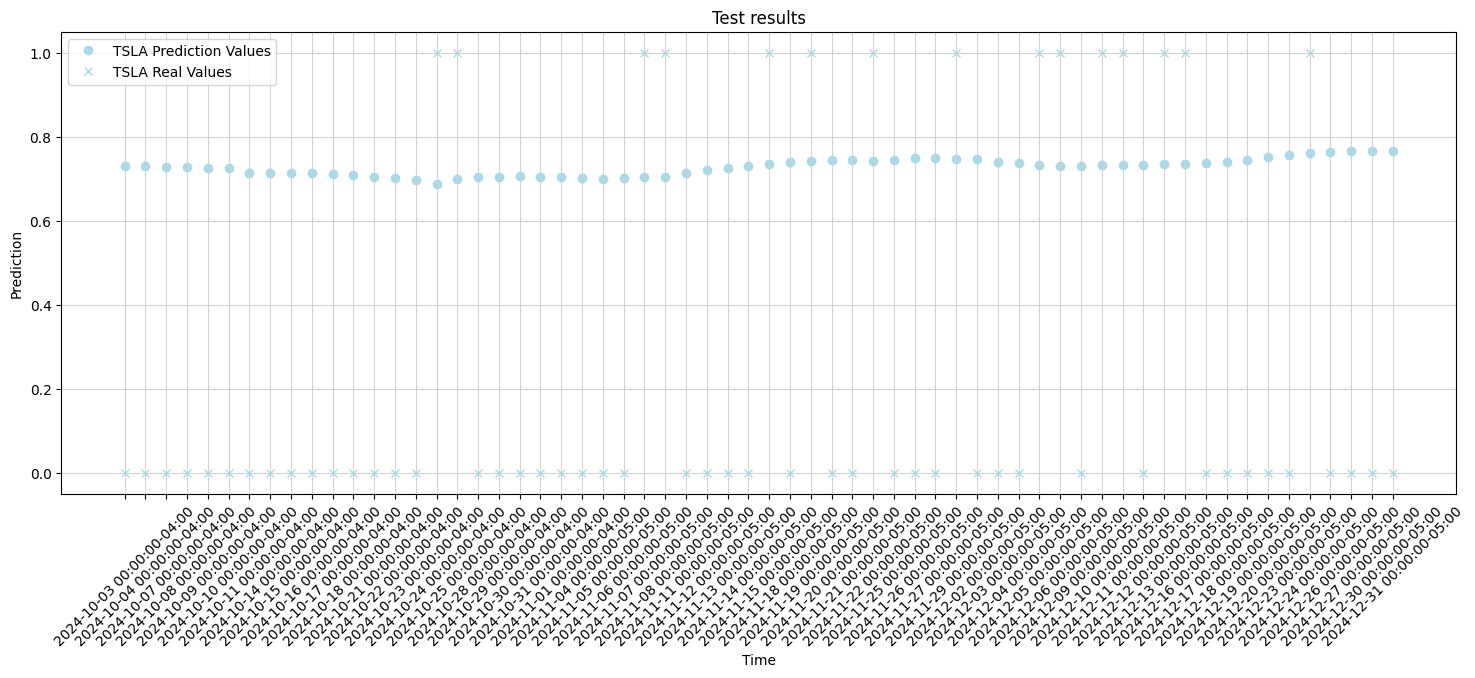

In [13]:


ticker_to_show = 'TSLA'

# Plot actual and predicted price
plt.figure(figsize=(18,6))
# plt.plot(tickers, y_predict, label="Prediction Values", color=test_predicted_color, marker='o', linestyle='')
plt.plot(data_frame[data_frame['Orig_Ticker'] == ticker_to_show]['Date'], data_frame[data_frame['Orig_Ticker'] == ticker_to_show]['y-predict'], label=f"{ticker_to_show} Prediction Values", color=train_predicted_color, marker='o', linestyle='')
plt.plot(data_frame[data_frame['Orig_Ticker'] == ticker_to_show]['Date'], data_frame[data_frame['Orig_Ticker'] == ticker_to_show]['y-value'], label=f"{ticker_to_show} Real Values", color=train_predicted_color, marker='x', linestyle='')
# plt.plot(y_test_with_dates[:, 0], y_test_predict[:,0][0:100], label="Training Predictions", linewidth=1, color=train_predicted_color)

# plt.plot(data_validate_dates, y_validate_inv, label="Validation Data", color=validate_actual_color)
# plt.plot(data_validate_dates, y_validate_predict_inv, label="Validation Predictions", linewidth=1, color=validate_predicted_color)

# plt.plot(data_test_dates, y_test_inv, label="Testing Data", color=test_actual_color)
# plt.plot(data_test_dates, y_test_predict_inv, label="Testing Predictions", linewidth=1, color=test_predicted_color)

plt.title("Test results")
plt.xlabel("Time")
plt.ylabel("Prediction")
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)
plt.legend()
plt.grid(color="lightgray")

In [14]:
# CALCULATE GAIN VS LOSS

gain = 0.02 * len(results[results[f"TP-{tr}"] == 1])
loss = 0.005 * len(results[results[f"FP-{tr}"] == 1])

print(f"gain is: {gain} and loss is {loss}")
print(f"Effective gain is: {gain - loss}")

gain is: 0.18 and loss is 0.095
Effective gain is: 0.08499999999999999
